In [8]:
# ==========================================
# UNEMPLOYMENT ANALYSIS WITH PYTHON
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("Unemployment.csv")

# Fix Column Names (remove spaces)
df.columns = df.columns.str.strip()

# Display First 5 Rows
print("First 5 Rows:")
print(df.head())

# Dataset Info
print("\nDataset Information:")
print(df.info())

# Dataset Shape
print("\nDataset Shape:")
print(df.shape)

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Drop Missing Values
df.dropna(inplace=True)



First 5 Rows:
           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 7

In [3]:
# Statistical Summary
print("\nStatistical Summary:")
print(df.describe())

# Column Names
print("\nColumn Names:")
print(df.columns.tolist())

# ==========================================
# Average Unemployment Rate by State
# ==========================================

state_unemployment = df.groupby(
    'Region'
)['Estimated Unemployment Rate (%)'].mean()

print("\nAverage Unemployment Rate by State:")
print(state_unemployment)

# Highest & Lowest
highest_state = state_unemployment.idxmax()
lowest_state = state_unemployment.idxmin()

print("\nHighest Unemployment State:", highest_state)
print("Lowest Unemployment State:", lowest_state)


Statistical Summary:
                                Date  Estimated Unemployment Rate (%)  \
count                            740                       740.000000   
mean   2019-12-12 18:36:58.378378496                        11.787946   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.657500   
50%              2019-11-30 00:00:00                         8.350000   
75%              2020-03-31 00:00:00                        15.887500   
max              2020-06-30 00:00:00                        76.740000   
std                              NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  
count        7.400000e+02                               740.000000  
mean         7.204460e+06                                42.630122  
min          4.942000e+04                                13.330000  
25%          1.190404e+06                   

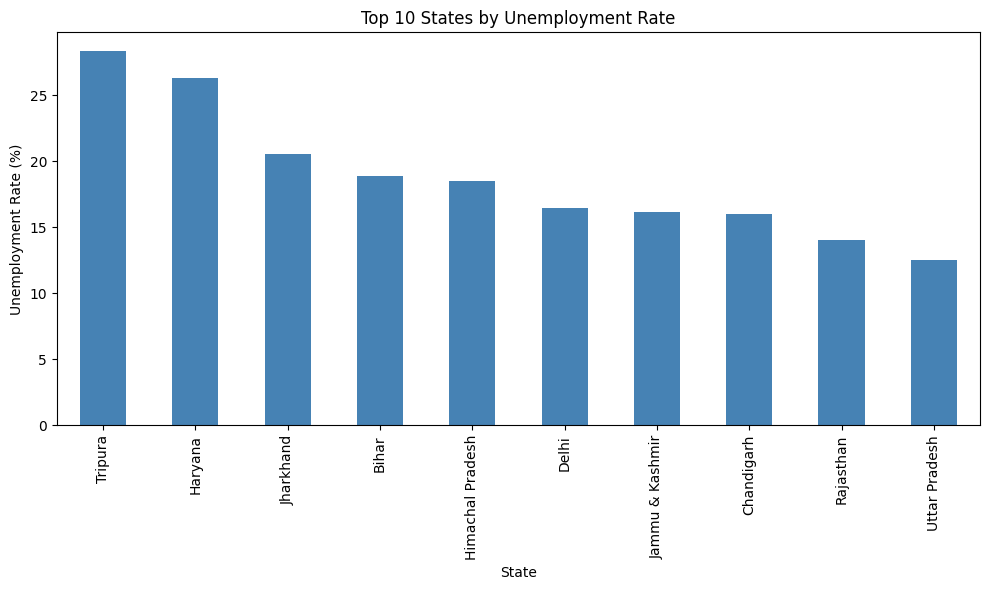

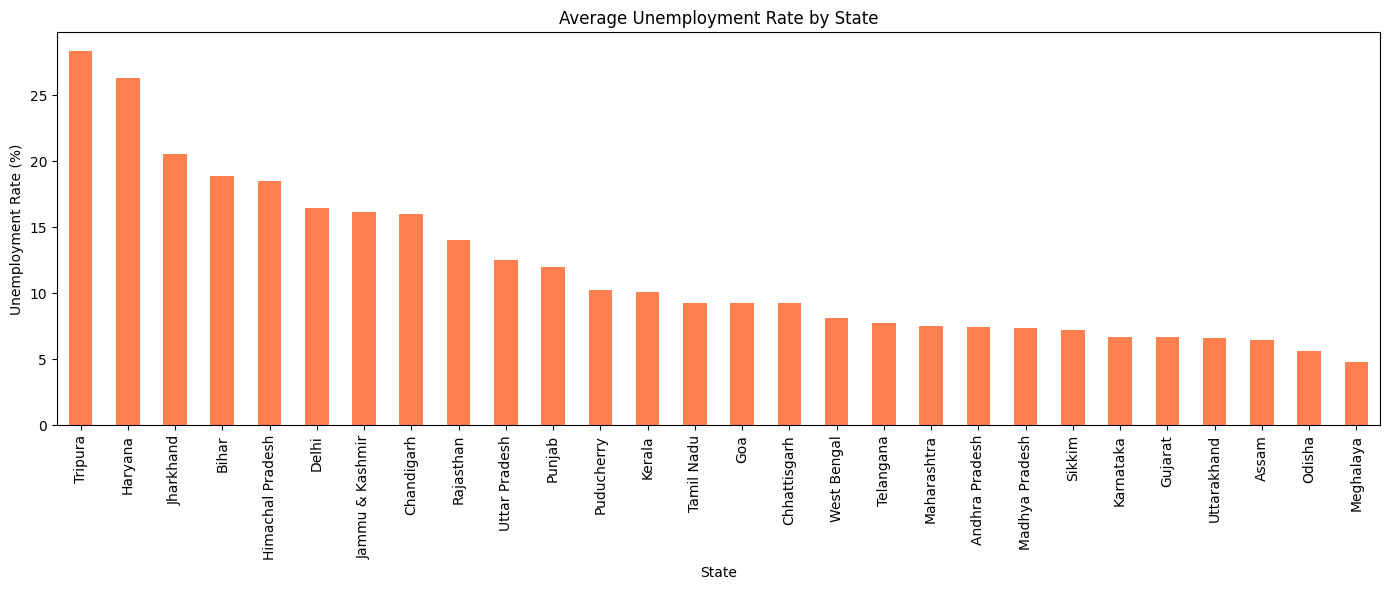

In [4]:
# ==========================================
# Top 10 States Bar Chart
# ==========================================

top10 = state_unemployment.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,6))
top10.plot(kind='bar', color='steelblue')
plt.title("Top 10 States by Unemployment Rate")
plt.xlabel("State")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.show()

# ==========================================
# All States Bar Chart
# ==========================================

plt.figure(figsize=(14,6))
state_unemployment.sort_values(ascending=False).plot(kind='bar', color='coral')
plt.title("Average Unemployment Rate by State")
plt.xlabel("State")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.show()

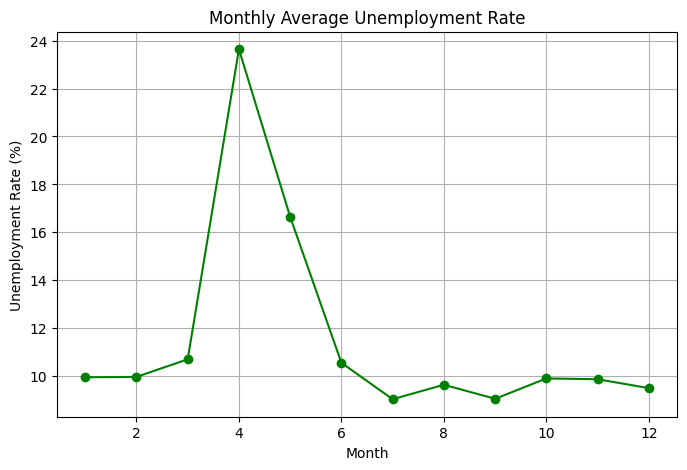

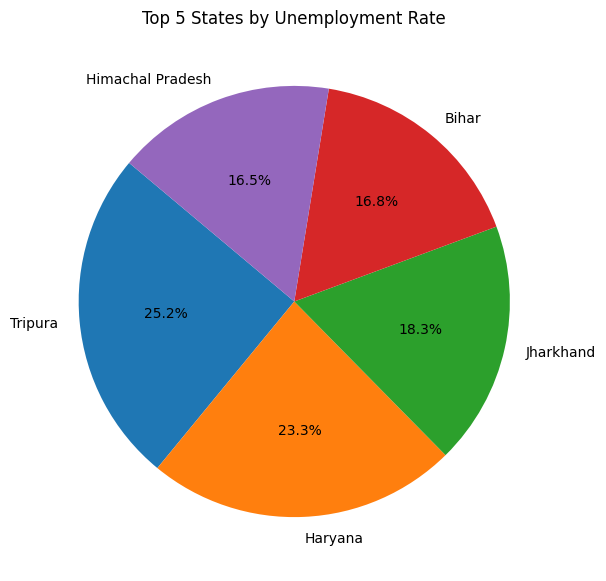

In [6]:
# ==========================================
# Monthly Trend Analysis
# ==========================================

# df['Date'] = pd.to_datetime(
#     df['Date'].str.strip(),
#     dayfirst=True
# )

monthly_avg = df.groupby(
    df['Date'].dt.month
)['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(8,5))
monthly_avg.plot(marker='o', color='green')
plt.title("Monthly Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.grid()
plt.show()

# ==========================================
# Pie Chart - Top 5 States
# ==========================================

top5 = state_unemployment.sort_values(
    ascending=False
).head(5)

plt.figure(figsize=(7,7))
plt.pie(
    top5,
    labels=top5.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Top 5 States by Unemployment Rate")
plt.show()


Correlation Matrix:
                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222876   
Estimated Labour Participation Rate (%)                         0.002558   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222876   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011300   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                         0.002558  
Estimated Employed                                                      0.011300  
Estimated Labour Participation Rate (%)                                 1.000000  


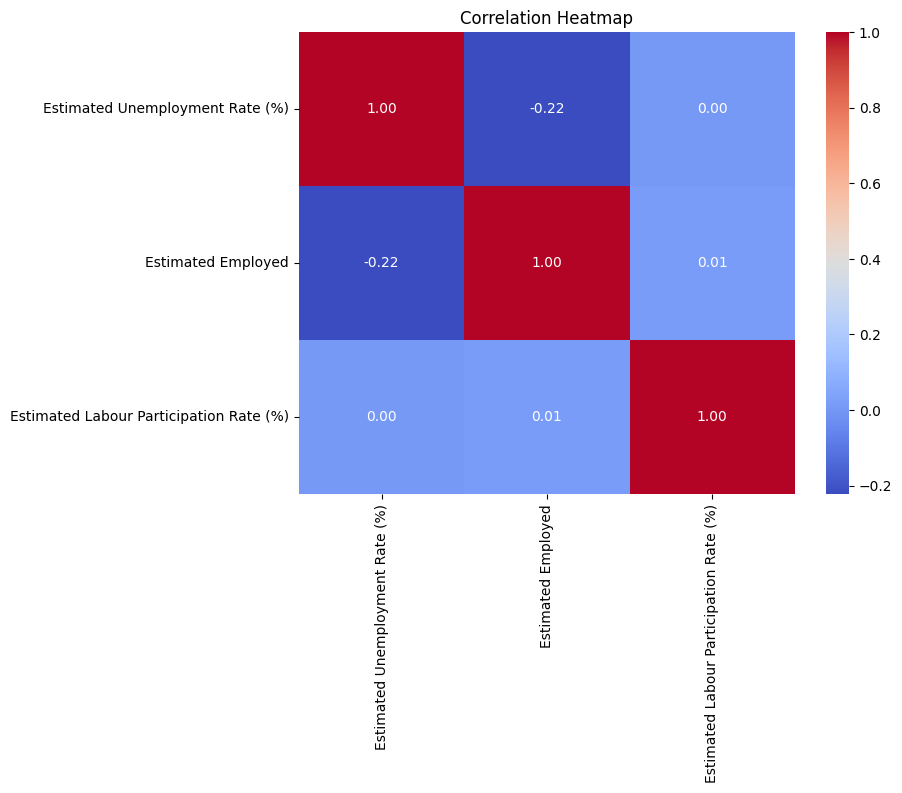


PROJECT INSIGHTS
--------------------
Highest Unemployment State: Tripura
Lowest Unemployment State: Meghalaya
Average Unemployment Rate: 11.80%

Project Completed Successfully


In [7]:
# ==========================================
# Correlation Analysis
# ==========================================

numeric_df = df.select_dtypes(include=np.number)
correlation = numeric_df.corr()

print("\nCorrelation Matrix:")
print(correlation)

plt.figure(figsize=(8,6))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# Insights
# ==========================================

print("\nPROJECT INSIGHTS")
print("--------------------")
print("Highest Unemployment State:", highest_state)
print("Lowest Unemployment State:", lowest_state)
print("Average Unemployment Rate: {:.2f}%".format(
    state_unemployment.mean()
))
print("\nProject Completed Successfully")